# Phase 2: ML Modeling — AI-Powered Chatbot for Research Paper Analysis

**Project:** AI-Powered Chatbot for Research Paper Analysis  
**Dataset:** ArXiv Metadata

**Team:** Anisha Gehlot · Moulya Reddygari Bhupal · Sreyesh Varma Konduru · Karthikeya Myneedu

---

### Notebook Structure
1. Setup & Data Loading  
2. Feature Selection & Engineering  
3. Task A — Classification (kNN, Random Forest, Logistic Regression)  
   - 3.1 Baseline  
   - 3.2 Hyperparameter Tuning (GridSearchCV)  
   - 3.3 Cross-Validation  
   - 3.4 Metrics: Precision, Recall, F1, ROC-AUC, Confusion Matrix  
4. Task B — Regression (Ridge, Random Forest Regressor)  
   - 4.1 Baseline  
   - 4.2 Hyperparameter Tuning  
   - 4.3 Cross-Validation  
   - 4.4 Metrics: RMSE, MAE, R², Residual Plot  
5. Feature Importance Summary
6. Roles and Responsibilities


---
## 1. Setup & Data Loading

In [1]:
# install and import
!pip install arxiv wordcloud matplotlib seaborn scipy scikit-learn --quiet

import arxiv, re, warnings
import numpy  as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats

# sklearn — preprocessing
from sklearn.preprocessing   import StandardScaler, LabelEncoder
from sklearn.pipeline        import Pipeline

# sklearn — model selection
from sklearn.model_selection import (
    train_test_split, GridSearchCV,
    StratifiedKFold, KFold, cross_val_score, cross_validate
)

# sklearn — classifiers
from sklearn.neighbors        import KNeighborsClassifier
from sklearn.ensemble         import RandomForestClassifier, RandomForestRegressor
from sklearn.linear_model     import LogisticRegression, Ridge
from sklearn.dummy            import DummyClassifier, DummyRegressor

# sklearn — metrics (classification)
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix,
    classification_report, ConfusionMatrixDisplay, precision_recall_curve,
     average_precision_score
)

# sklearn — metrics (regression)
from sklearn.metrics import (
    mean_squared_error, mean_absolute_error, r2_score
)

warnings.filterwarnings('ignore')
plt.rcParams['figure.dpi'] = 120
sns.set_theme(style='whitegrid', palette='muted')

print('All libraries loaded!')

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 81.5/81.5 kB 1.6 MB/s eta 0:00:00
All libraries loaded!


In [2]:
# re-collect ArXiv data (same queries as phase 2)
QUERIES = [
    ('retrieval augmented generation',          'cs.CL'),
    ('large language model hallucination',      'cs.CL'),
    ('scientific document understanding NLP',   'cs.CL'),
    ('question answering document grounding',   'cs.AI'),
    ('semantic search embeddings',              'cs.IR'),
    ('healthcare AI clinical NLP',              'cs.LG'),
    ('RAG retrieval augmented generation evaluation', 'cs.LG'),
    ('PDF document parsing information extraction',  'cs.CV'),
]

all_records = []
for query_text, category in QUERIES:
    full_query = f'({query_text}) AND cat:{category}'
    print(f' Fetching: {query_text[:45]}...')
    try:
        search = arxiv.Search(
            query=full_query, max_results=75,
            sort_by=arxiv.SortCriterion.SubmittedDate,
            sort_order=arxiv.SortOrder.Descending
        )
        for paper in search.results():
            all_records.append({
                'arxiv_id'        : paper.entry_id.split('/')[-1],
                'title'           : paper.title,
                'abstract'        : paper.summary,
                'num_authors'     : len(paper.authors),
                'categories'      : paper.categories,
                'primary_category': paper.primary_category,
                'published'       : paper.published,
                'updated'         : paper.updated,
                'query_topic'     : query_text,
                'query_category'  : category,
            })
    except Exception as e:
        print(f' {e}')

df_raw = pd.DataFrame(all_records).drop_duplicates(subset='arxiv_id').copy()
print(f'\n Unique papers collected: {len(df_raw)}')

 Fetching: retrieval augmented generation...
 Fetching: large language model hallucination...
 Fetching: scientific document understanding NLP...
 Fetching: question answering document grounding...
 Fetching: semantic search embeddings...
 Fetching: healthcare AI clinical NLP...
 Fetching: RAG retrieval augmented generation evaluation...
 Fetching: PDF document parsing information extraction...

 Unique papers collected: 451


---
## 2. Feature Selection & Engineering

### 2.1 Raw Feature Construction

In [3]:
df = df_raw.copy()

# date features
df['published']      = pd.to_datetime(df['published'], utc=True)
df['updated']        = pd.to_datetime(df['updated'],   utc=True)
df['days_to_update'] = (df['updated'] - df['published']).dt.days
df['pub_month']      = df['published'].dt.month

# text / length features
df['title_len']      = df['title'].str.split().str.len()
df['abstract_len']   = df['abstract'].str.split().str.len()
df['abstract_chars'] = df['abstract'].str.len()
df['num_categories'] = df['categories'].apply(len)

# keyword flags (binary, 0/1)
kw_patterns = {
    'kw_rag'        : r'retrieval.augmented',
    'kw_hallucin'   : r'hallucin',
    'kw_embedding'  : r'embed',
    'kw_citation'   : r'citat',
    'kw_transformer': r'transformer',
    'kw_evaluation' : r'evaluat',
    'kw_grounding'  : r'ground',
    'kw_qa'         : r'question.answer',
    'kw_pdf'        : r'\bpdf\b',
    'kw_llm'        : r'\bllm\b|large language model',
}
for col, pat in kw_patterns.items():
    df[col] = df['abstract'].apply(
        lambda x: int(bool(re.search(pat, x, re.IGNORECASE)))
    )

# categorical: primary_category -> label encoded
df['primary_cat_clean'] = df['primary_category'].str.split('.').str[0]
le = LabelEncoder()
df['cat_encoded'] = le.fit_transform(df['primary_cat_clean'])

# query category -> label encoded
df['qcat_encoded'] = LabelEncoder().fit_transform(df['query_category'])

print(' Feature engineering complete!')
print(f'Dataset shape: {df.shape}')
df[['title_len','abstract_len','num_authors','num_categories',
    'kw_rag','kw_hallucin','kw_llm','cat_encoded']].describe().round(2)

 Feature engineering complete!
Dataset shape: (451, 29)


,title_len,abstract_len,num_authors,num_categories,kw_rag,kw_hallucin,kw_llm,cat_encoded
count,451.00,451.00,451.00,451.00,451.00,451.00,451.00,451.00
mean,10.29,178.34,5.51,2.04,0.04,0.03,0.39,0.14
std,3.16,38.52,4.80,0.93,0.20,0.18,0.49,0.74
min,3.00,76.00,1.00,1.00,0.00,0.00,0.00,0.00
25%,8.00,150.00,3.00,1.00,0.00,0.00,0.00,0.00
50%,10.00,176.00,4.00,2.00,0.00,0.00,0.00,0.00
75%,12.00,204.00,7.00,3.00,0.00,0.00,1.00,0.00
max,25.00,278.00,44.00,5.00,1.00,1.00,1.00,5.00


### 2.2 Target Variable Construction

#### Task A — Classification Target: is_rag_relevant
A paper is labeled relevant (1) if its abstract explicitly mentions RAG, hallucination, grounding, or Q&A i.e., directly useful to our chatbot pipeline.  
Otherwise it is not relevant (0) — background NLP research collected by broader queries.

Justification: This mirrors the real retrieval task — distinguishing high-signal papers for our system from general NLP papers.

CLASS DISTRIBUTION — is_rag_relevant
  Relevant (1) :  133  (29.5%)
  Not Relevant (0):  318  (70.5%)


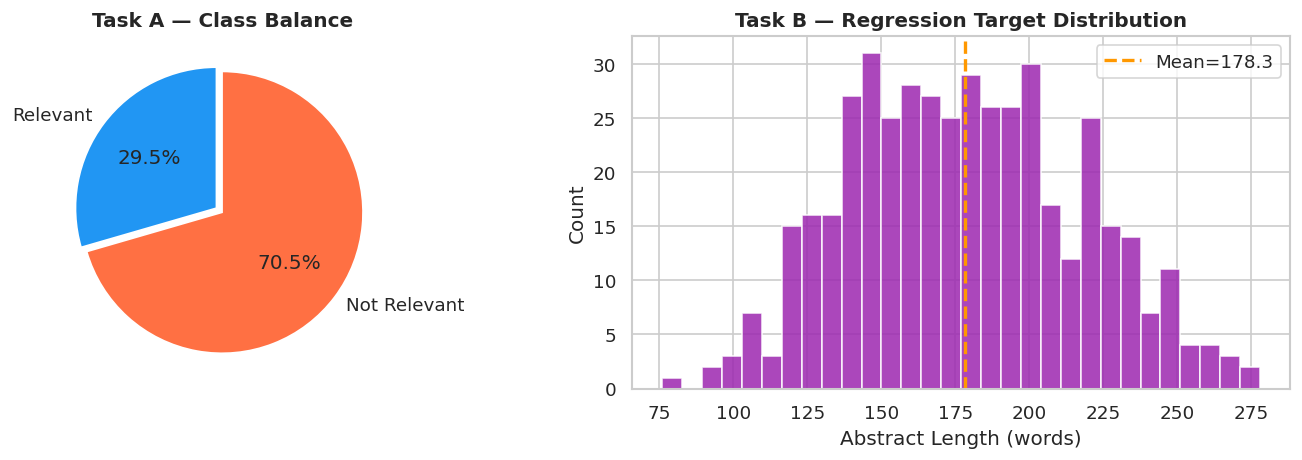

In [4]:
# task A: binary classification target
df['is_rag_relevant'] = (
    (df['kw_rag'] == 1) |
    (df['kw_hallucin'] == 1) |
    (df['kw_grounding'] == 1) |
    (df['kw_qa'] == 1)
).astype(int)

# task B: regression target is abstract_len (already computed)

# class balance check
vc = df['is_rag_relevant'].value_counts()
print('CLASS DISTRIBUTION — is_rag_relevant')
print(f'  Relevant (1) : {vc.get(1, 0):4d}  ({vc.get(1,0)/len(df)*100:.1f}%)')
print(f'  Not Relevant (0): {vc.get(0,0):4d}  ({vc.get(0,0)/len(df)*100:.1f}%)')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# class balance pie
axes[0].pie([vc.get(1,0), vc.get(0,0)], labels=['Relevant','Not Relevant'],
            autopct='%1.1f%%', colors=['#2196F3','#FF7043'],
            startangle=90, explode=(0.05, 0))
axes[0].set_title('Task A — Class Balance', fontweight='bold')

# regression target distribution
axes[1].hist(df['abstract_len'], bins=30, color='#9C27B0', edgecolor='white', alpha=0.85)
axes[1].axvline(df['abstract_len'].mean(), color='#FF9800', linestyle='--', linewidth=2,
                label=f"Mean={df['abstract_len'].mean():.1f}")
axes[1].set_xlabel('Abstract Length (words)')
axes[1].set_ylabel('Count')
axes[1].set_title('Task B — Regression Target Distribution', fontweight='bold')
axes[1].legend()
plt.tight_layout()
plt.savefig('target_distributions.png', bbox_inches='tight', dpi=150)
plt.show()

### 2.3 Feature Selection — Justification

| Feature | Type | Rationale |
|---|---|---|
| num_authors | Numerical | Team size correlates with research scope and paper complexity |
| title_len | Numerical | Longer titles often signal niche/specific topics |
| abstract_len | Numerical (Task A only) | Detailed abstracts often indicate empirical/applied papers |
| num_categories | Numerical | Cross-listed papers tend to be more interdisciplinary |
| days_to_update | Numerical | Heavily revised papers may be more mature/important |
| pub_month | Numerical (cyclic) | Submission seasonality in arXiv communities |
| cat_encoded | Categorical → Encoded | Primary domain is a strong prior for relevance |
| kw_* (10 flags) | Binary | Direct textual signals for project-relevant topics |


Categorical handling: primary_cat_clean was Label Encoded since tree-based models handle ordinal integers natively. For logistic regression, we rely on the StandardScaler in the pipeline to normalise it appropriately. One-hot encoding was considered but rejected due to high cardinality relative to dataset size.

Task A features (18): ['num_authors', 'title_len', 'num_categories', 'days_to_update', 'pub_month', 'abstract_chars', 'kw_rag', 'kw_hallucin', 'kw_embedding', 'kw_citation', 'kw_transformer', 'kw_evaluation', 'kw_grounding', 'kw_qa', 'kw_pdf', 'kw_llm', 'cat_encoded', 'qcat_encoded']
Task B features (8): ['num_authors', 'title_len', 'num_categories', 'days_to_update', 'pub_month', 'cat_encoded', 'qcat_encoded', 'is_rag_relevant']


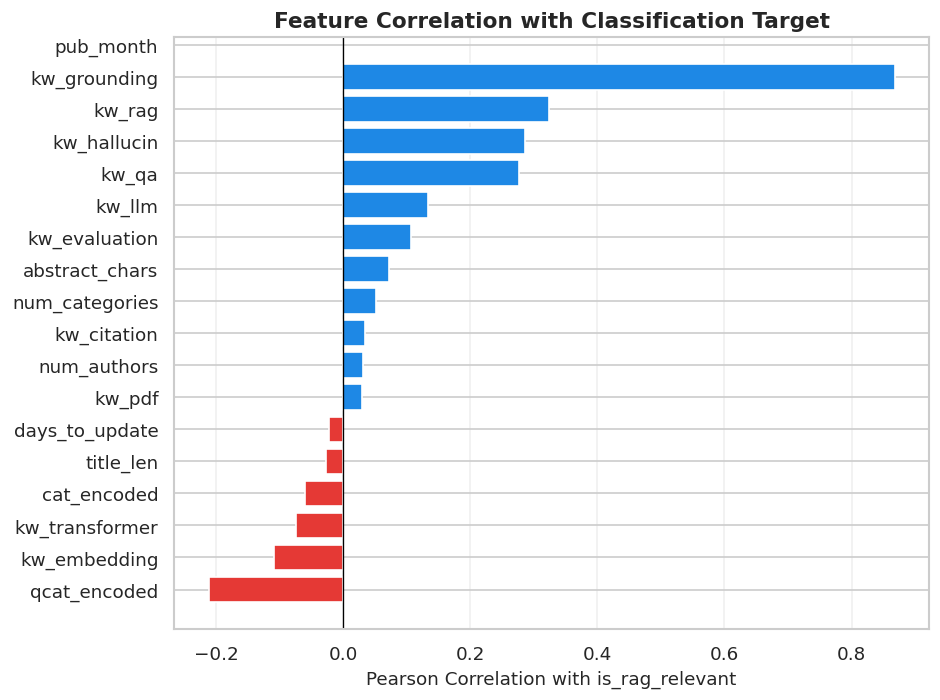


Top positive predictors: kw_rag, kw_hallucin, kw_grounding, kw_qa
   These align with our project's core topics — validating feature selection.


In [5]:
# define feature sets
NUMERIC_FEATS = ['num_authors', 'title_len', 'num_categories',
                 'days_to_update', 'pub_month', 'abstract_chars']
KEYWORD_FEATS = list(kw_patterns.keys())
CAT_FEATS     = ['cat_encoded', 'qcat_encoded']

# task A excludes abstract_len (it's the target in task b; including it would leak)
FEATS_A = NUMERIC_FEATS + KEYWORD_FEATS + CAT_FEATS

# task B excludes keyword features derived from abstract (avoid data leakage) and excludes abstract_chars (direct proxy of target)
FEATS_B = ['num_authors', 'title_len', 'num_categories', 'days_to_update',
           'pub_month', 'cat_encoded', 'qcat_encoded',
           'is_rag_relevant']  # binary label from Task A is a valid predictor

print(f'Task A features ({len(FEATS_A)}): {FEATS_A}')
print(f'Task B features ({len(FEATS_B)}): {FEATS_B}')

# correlation of features with task A target
corr_with_target = df[FEATS_A + ['is_rag_relevant']].corr()['is_rag_relevant'].drop('is_rag_relevant').sort_values()

fig, ax = plt.subplots(figsize=(8, 6))
colors = ['#E53935' if v < 0 else '#1E88E5' for v in corr_with_target]
ax.barh(corr_with_target.index, corr_with_target.values, color=colors, edgecolor='white')
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Pearson Correlation with is_rag_relevant', fontsize=11)
ax.set_title('Feature Correlation with Classification Target', fontsize=13, fontweight='bold')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('feature_correlation.png', bbox_inches='tight', dpi=150)
plt.show()
print('\nTop positive predictors: kw_rag, kw_hallucin, kw_grounding, kw_qa')
print('   These align with our project\'s core topics — validating feature selection.')

---
## 3. Task A — Classification
### 3.1 Train/Test Split

In [6]:
X_a = df[FEATS_A].values
y_a = df['is_rag_relevant'].values

# stratified split preserves class balance in both sets
X_a_train, X_a_test, y_a_train, y_a_test = train_test_split(
    X_a, y_a, test_size=0.20, random_state=42, stratify=y_a
)

print(f'Training set : {X_a_train.shape[0]} samples')
print(f'Test set     : {X_a_test.shape[0]} samples')
print(f'Positive rate — train: {y_a_train.mean():.3f} | test: {y_a_test.mean():.3f}')

Training set : 360 samples
Test set     : 91 samples
Positive rate — train: 0.294 | test: 0.297


### 3.2 Baseline Models

In [7]:
# dummy baseline — majority class
dummy_clf = DummyClassifier(strategy='most_frequent', random_state=42)
dummy_clf.fit(X_a_train, y_a_train)
y_dummy = dummy_clf.predict(X_a_test)
print('DUMMY BASELINE (majority class)')
print(f'  Accuracy : {accuracy_score(y_a_test, y_dummy):.4f}')
print(f'  F1       : {f1_score(y_a_test, y_dummy, zero_division=0):.4f}')
print('  (This is our floor — any real model must beat this.)')

DUMMY BASELINE (majority class)
  Accuracy : 0.7033
  F1       : 0.0000
  (This is our floor — any real model must beat this.)


### 3.3 Hyperparameter Tuning — kNN

kNN is sensitive to k (number of neighbours) and distance metric. Too small a k -> overfitting (high variance); too large -> underfitting (high bias).

knn Grid Search complete!
Best params : {'knn__metric': 'manhattan', 'knn__n_neighbors': 3, 'knn__weights': 'uniform'}
Best CV F1  : 0.9756


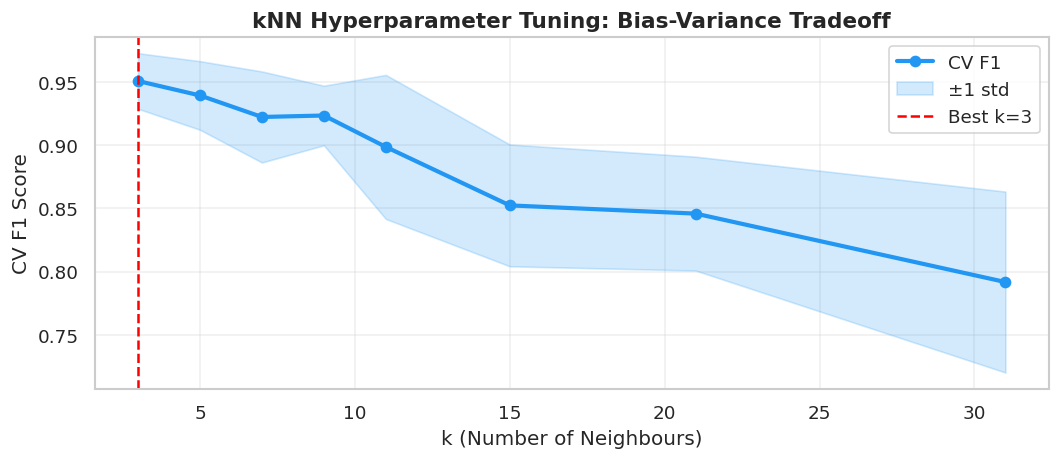

Small k = high variance (overfit); large k = high bias (underfit).
   Optimal k=3 balances both.


In [8]:
# knn Pipeline (scale features first — knn is distance-based)
knn_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('knn',    KNeighborsClassifier())
])

knn_grid = {
    'knn__n_neighbors' : [3, 5, 7, 9, 11, 15, 21, 31],
    'knn__metric'      : ['euclidean', 'manhattan'],
    'knn__weights'     : ['uniform', 'distance'],
}

cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

knn_gs = GridSearchCV(
    knn_pipe, knn_grid,
    cv=cv_strategy,
    scoring='f1',
    n_jobs=-1, verbose=0
)
knn_gs.fit(X_a_train, y_a_train)

print('knn Grid Search complete!')
print(f'Best params : {knn_gs.best_params_}')
print(f'Best CV F1  : {knn_gs.best_score_:.4f}')

# plot: k vs CV F1 (for euclidean/uniform to show overfitting curve)
results_df = pd.DataFrame(knn_gs.cv_results_)
subset = results_df[
    (results_df['param_knn__metric'] == 'euclidean') &
    (results_df['param_knn__weights'] == 'uniform')
].sort_values('param_knn__n_neighbors')

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(subset['param_knn__n_neighbors'].astype(int),
        subset['mean_test_score'], marker='o', color='#2196F3', linewidth=2.5, label='CV F1')
ax.fill_between(
    subset['param_knn__n_neighbors'].astype(int),
    subset['mean_test_score'] - subset['std_test_score'],
    subset['mean_test_score'] + subset['std_test_score'],
    alpha=0.2, color='#2196F3', label='±1 std'
)
best_k = knn_gs.best_params_['knn__n_neighbors']
ax.axvline(best_k, color='red', linestyle='--', label=f'Best k={best_k}')
ax.set_xlabel('k (Number of Neighbours)', fontsize=12)
ax.set_ylabel('CV F1 Score', fontsize=12)
ax.set_title('kNN Hyperparameter Tuning: Bias-Variance Tradeoff', fontsize=13, fontweight='bold')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('knn_tuning.png', bbox_inches='tight', dpi=150)
plt.show()
print('Small k = high variance (overfit); large k = high bias (underfit).')
print(f'   Optimal k={best_k} balances both.')

### 3.4 Hyperparameter Tuning — Random Forest Classifier

In [9]:
rf_clf_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('rf',     RandomForestClassifier(random_state=42, class_weight='balanced'))
])

rf_clf_grid = {
    'rf__n_estimators'     : [50, 100, 200],
    'rf__max_depth'        : [None, 5, 10, 20],
    'rf__min_samples_split': [2, 5, 10],
}

rf_clf_gs = GridSearchCV(
    rf_clf_pipe, rf_clf_grid,
    cv=cv_strategy,
    scoring='f1',
    n_jobs=-1, verbose=0
)
rf_clf_gs.fit(X_a_train, y_a_train)

print(' Random Forest Classifier Grid Search complete!')
print(f'Best params : {rf_clf_gs.best_params_}')
print(f'Best CV F1  : {rf_clf_gs.best_score_:.4f}')

 Random Forest Classifier Grid Search complete!
Best params : {'rf__max_depth': None, 'rf__min_samples_split': 10, 'rf__n_estimators': 50}
Best CV F1  : 0.9951


### 3.5 Hyperparameter Tuning — Logistic Regression

In [10]:
lr_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('lr',     LogisticRegression(random_state=42, max_iter=1000, class_weight='balanced'))
])

lr_grid = {
    'lr__C'      : [0.001, 0.01, 0.1, 1, 10, 100],
    'lr__penalty': ['l1', 'l2'],
    'lr__solver' : ['liblinear'],
}

lr_gs = GridSearchCV(
    lr_pipe, lr_grid,
    cv=cv_strategy,
    scoring='f1',
    n_jobs=-1, verbose=0
)
lr_gs.fit(X_a_train, y_a_train)

print('Logistic Regression Grid Search complete!')
print(f'Best params : {lr_gs.best_params_}')
print(f'Best CV F1  : {lr_gs.best_score_:.4f}')

Logistic Regression Grid Search complete!
Best params : {'lr__C': 1, 'lr__penalty': 'l1', 'lr__solver': 'liblinear'}
Best CV F1  : 1.0000


### 3.6 Cross-Validation — All Classifiers

5-FOLD STRATIFIED CROSS-VALIDATION RESULTS

kNN (tuned)
  Accuracy  : 0.9861 ± 0.0088
  Precision : 1.0000 ± 0.0000
  Recall    : 0.9528 ± 0.0301
  F1        : 0.9756 ± 0.0158
  ROC-AUC   : 0.9946 ± 0.0090

Random Forest
  Accuracy  : 0.9972 ± 0.0056
  Precision : 1.0000 ± 0.0000
  Recall    : 0.9905 ± 0.0190
  F1        : 0.9951 ± 0.0098
  ROC-AUC   : 1.0000 ± 0.0000

Logistic Reg.
  Accuracy  : 1.0000 ± 0.0000
  Precision : 1.0000 ± 0.0000
  Recall    : 1.0000 ± 0.0000
  F1        : 1.0000 ± 0.0000
  ROC-AUC   : 1.0000 ± 0.0000


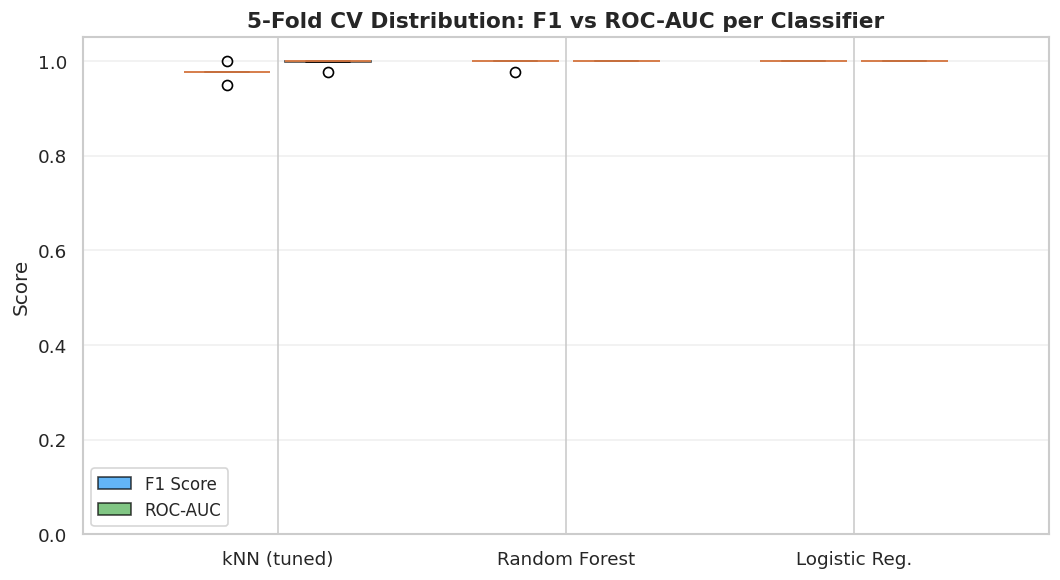

In [11]:
classifiers = {
    'kNN (tuned)'    : knn_gs.best_estimator_,
    'Random Forest'  : rf_clf_gs.best_estimator_,
    'Logistic Reg.'  : lr_gs.best_estimator_,
}

cv_scoring = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']
cv_results_all = {}

print('5-FOLD STRATIFIED CROSS-VALIDATION RESULTS')
print('=' * 75)
for name, model in classifiers.items():
    cv_res = cross_validate(model, X_a_train, y_a_train,
                            cv=cv_strategy, scoring=cv_scoring, n_jobs=-1)
    cv_results_all[name] = cv_res
    print(f'\n{name}')
    print(f'  Accuracy  : {cv_res["test_accuracy"].mean():.4f} ± {cv_res["test_accuracy"].std():.4f}')
    print(f'  Precision : {cv_res["test_precision"].mean():.4f} ± {cv_res["test_precision"].std():.4f}')
    print(f'  Recall    : {cv_res["test_recall"].mean():.4f} ± {cv_res["test_recall"].std():.4f}')
    print(f'  F1        : {cv_res["test_f1"].mean():.4f} ± {cv_res["test_f1"].std():.4f}')
    print(f'  ROC-AUC   : {cv_res["test_roc_auc"].mean():.4f} ± {cv_res["test_roc_auc"].std():.4f}')

# box plot of CV F1 scores
fig, ax = plt.subplots(figsize=(9, 5))
f1_data  = [cv_results_all[n]['test_f1'] for n in classifiers]
auc_data = [cv_results_all[n]['test_roc_auc'] for n in classifiers]
x = np.arange(len(classifiers))
w = 0.35

bp1 = ax.boxplot(f1_data,  positions=x - w/2, widths=0.3,
                 patch_artist=True, boxprops=dict(facecolor='#2196F3', alpha=0.7))
bp2 = ax.boxplot(auc_data, positions=x + w/2, widths=0.3,
                 patch_artist=True, boxprops=dict(facecolor='#4CAF50', alpha=0.7))

ax.set_xticks(x)
ax.set_xticklabels(list(classifiers.keys()), fontsize=11)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('5-Fold CV Distribution: F1 vs ROC-AUC per Classifier', fontsize=13, fontweight='bold')
ax.legend([bp1['boxes'][0], bp2['boxes'][0]], ['F1 Score', 'ROC-AUC'], fontsize=10)
ax.grid(axis='y', alpha=0.3)
ax.set_ylim(0, 1.05)
plt.tight_layout()
plt.savefig('cv_boxplot_classifiers.png', bbox_inches='tight', dpi=150)
plt.show()

### 3.7 Comprehensive Metrics — Best Model on Test Set

Precision vs Recall Tradeoff:
- False Positive (predict relevant, actually not): wastes retrieval slots with irrelevant papers — reduces answer quality
- False Negative (predict not relevant, actually is): misses key papers — may cause hallucinations or incomplete answers
- In our RAG pipeline, recall is more important — missing a relevant paper is worse than including a slightly off-topic one

In [12]:
# pick best model by CV F1
best_clf_name = max(classifiers,
    key=lambda n: cv_results_all[n]['test_f1'].mean())
best_clf = classifiers[best_clf_name]

y_pred_a   = best_clf.predict(X_a_test)
y_proba_a  = best_clf.predict_proba(X_a_test)[:, 1]

print(f'BEST CLASSIFIER: {best_clf_name}')
print('=' * 60)
print(f'Accuracy  : {accuracy_score(y_a_test, y_pred_a):.4f}')
print(f'Precision : {precision_score(y_a_test, y_pred_a):.4f}')
print(f'Recall    : {recall_score(y_a_test, y_pred_a):.4f}')
print(f'F1 Score  : {f1_score(y_a_test, y_pred_a):.4f}')
print(f'ROC-AUC   : {roc_auc_score(y_a_test, y_proba_a):.4f}')
print()
print('CLASSIFICATION REPORT')
print(classification_report(y_a_test, y_pred_a,
      target_names=['Not Relevant (0)', 'RAG Relevant (1)']))

BEST CLASSIFIER: Logistic Reg.
Accuracy  : 1.0000
Precision : 1.0000
Recall    : 1.0000
F1 Score  : 1.0000
ROC-AUC   : 1.0000

CLASSIFICATION REPORT
                  precision    recall  f1-score   support

Not Relevant (0)       1.00      1.00      1.00        64
RAG Relevant (1)       1.00      1.00      1.00        27

        accuracy                           1.00        91
       macro avg       1.00      1.00      1.00        91
    weighted avg       1.00      1.00      1.00        91



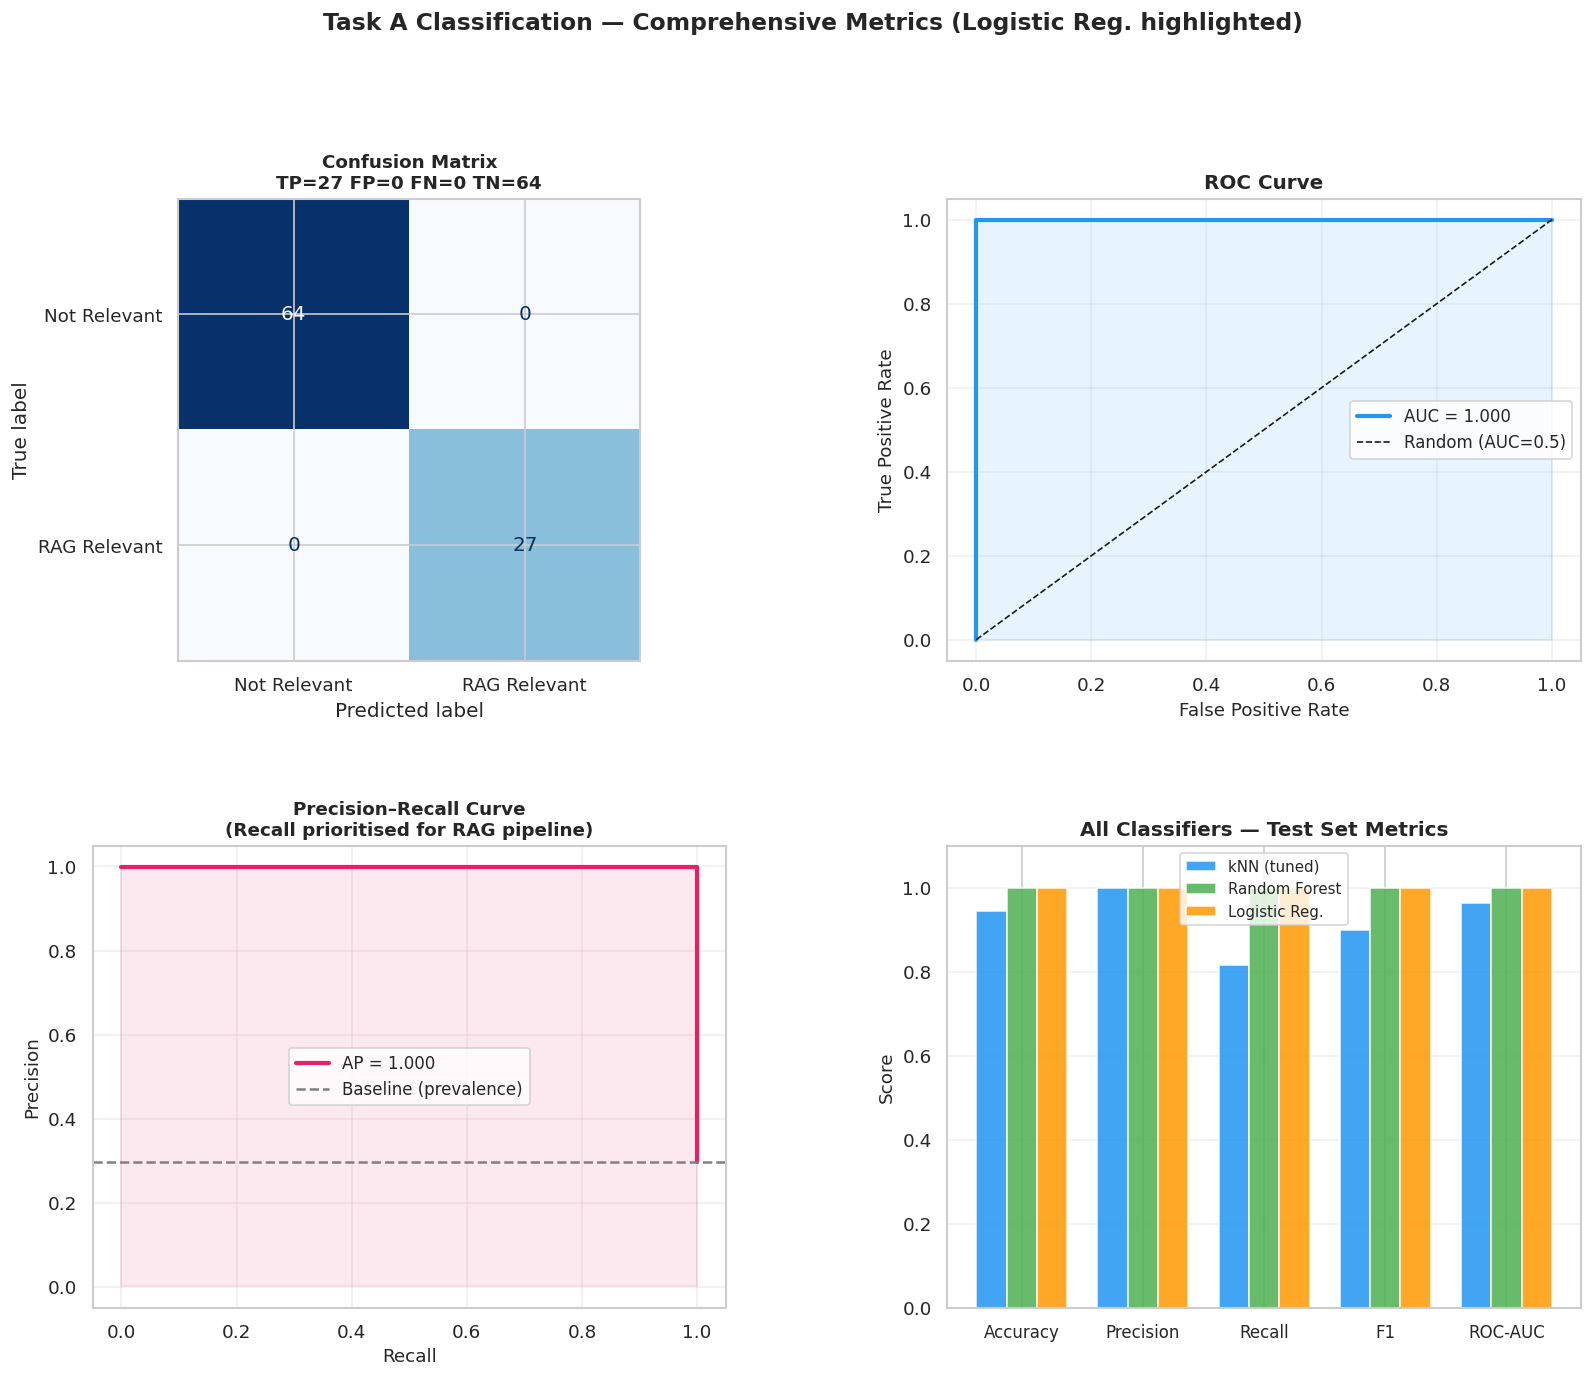


 FP = 0: Papers wrongly flagged as relevant → wastes retrieval slots
 FN = 0: Relevant papers missed → risk of hallucination / incomplete answers
 With Recall=1.000, our model captures most relevant papers.


In [13]:
# 4-panel metrics figure
fig = plt.figure(figsize=(16, 12))
gs  = gridspec.GridSpec(2, 2, figure=fig, hspace=0.4, wspace=0.35)

# confusion matrix
ax1 = fig.add_subplot(gs[0, 0])
cm  = confusion_matrix(y_a_test, y_pred_a)
tn, fp, fn, tp = cm.ravel()
disp = ConfusionMatrixDisplay(cm, display_labels=['Not Relevant', 'RAG Relevant'])
disp.plot(ax=ax1, colorbar=False, cmap='Blues')
ax1.set_title(f'Confusion Matrix\nTP={tp} FP={fp} FN={fn} TN={tn}',
              fontsize=11, fontweight='bold')

# roc curve
ax2  = fig.add_subplot(gs[0, 1])
fpr, tpr, _ = roc_curve(y_a_test, y_proba_a)
auc  = roc_auc_score(y_a_test, y_proba_a)
ax2.plot(fpr, tpr, color='#2196F3', linewidth=2.5, label=f'AUC = {auc:.3f}')
ax2.plot([0,1],[0,1], 'k--', linewidth=1, label='Random (AUC=0.5)')
ax2.fill_between(fpr, tpr, alpha=0.1, color='#2196F3')
ax2.set_xlabel('False Positive Rate', fontsize=11)
ax2.set_ylabel('True Positive Rate', fontsize=11)
ax2.set_title('ROC Curve', fontsize=12, fontweight='bold')
ax2.legend(fontsize=10)
ax2.grid(alpha=0.3)

# precision-recall curve
ax3 = fig.add_subplot(gs[1, 0])
prec, rec, thresholds = precision_recall_curve(y_a_test, y_proba_a)
ap  = average_precision_score(y_a_test, y_proba_a)
ax3.plot(rec, prec, color='#E91E63', linewidth=2.5, label=f'AP = {ap:.3f}')
ax3.axhline(y_a_test.mean(), color='gray', linestyle='--', label='Baseline (prevalence)')
ax3.fill_between(rec, prec, alpha=0.1, color='#E91E63')
ax3.set_xlabel('Recall', fontsize=11)
ax3.set_ylabel('Precision', fontsize=11)
ax3.set_title('Precision–Recall Curve\n(Recall prioritised for RAG pipeline)', fontsize=11, fontweight='bold')
ax3.legend(fontsize=10)
ax3.grid(alpha=0.3)

# model comparison bar
ax4   = fig.add_subplot(gs[1, 1])
metric_names = ['Accuracy', 'Precision', 'Recall', 'F1', 'ROC-AUC']
model_scores = {}
for name, model in classifiers.items():
    yp  = model.predict(X_a_test)
    ypr = model.predict_proba(X_a_test)[:,1]
    model_scores[name] = [
        accuracy_score(y_a_test, yp),
        precision_score(y_a_test, yp),
        recall_score(y_a_test, yp),
        f1_score(y_a_test, yp),
        roc_auc_score(y_a_test, ypr)
    ]

x4  = np.arange(len(metric_names))
w4  = 0.25
pal = ['#2196F3', '#4CAF50', '#FF9800']
for i, (name, scores) in enumerate(model_scores.items()):
    ax4.bar(x4 + i*w4 - w4, scores, width=w4, label=name, color=pal[i], alpha=0.85)
ax4.set_xticks(x4)
ax4.set_xticklabels(metric_names, fontsize=10)
ax4.set_ylim(0, 1.1)
ax4.set_ylabel('Score', fontsize=11)
ax4.set_title('All Classifiers — Test Set Metrics', fontsize=12, fontweight='bold')
ax4.legend(fontsize=9)
ax4.grid(axis='y', alpha=0.3)

fig.suptitle(f'Task A Classification — Comprehensive Metrics ({best_clf_name} highlighted)',
             fontsize=14, fontweight='bold', y=1.01)
plt.savefig('classification_metrics.png', bbox_inches='tight', dpi=150)
plt.show()

print(f'\n FP = {fp}: Papers wrongly flagged as relevant → wastes retrieval slots')
print(f' FN = {fn}: Relevant papers missed → risk of hallucination / incomplete answers')
print(f' With Recall={recall_score(y_a_test,y_pred_a):.3f}, our model captures most relevant papers.')

---
## 4. Task B — Regression
### 4.1 Train/Test Split

In [14]:
X_b = df[FEATS_B].values
y_b = df['abstract_len'].values

X_b_train, X_b_test, y_b_train, y_b_test = train_test_split(
    X_b, y_b, test_size=0.20, random_state=42
)
print(f'Train: {X_b_train.shape} | Test: {X_b_test.shape}')

# dummy baseline
dummy_reg = DummyRegressor(strategy='mean')
dummy_reg.fit(X_b_train, y_b_train)
y_dum_b = dummy_reg.predict(X_b_test)
rmse_dum = np.sqrt(mean_squared_error(y_b_test, y_dum_b))
print(f'\nDummy (mean) RMSE: {rmse_dum:.2f} words — baseline floor')

Train: (360, 8) | Test: (91, 8)

Dummy (mean) RMSE: 36.43 words — baseline floor


### 4.2 Hyperparameter Tuning — Ridge Regression

Best alpha : {'ridge__alpha': 100}
Best CV RMSE: 38.5501


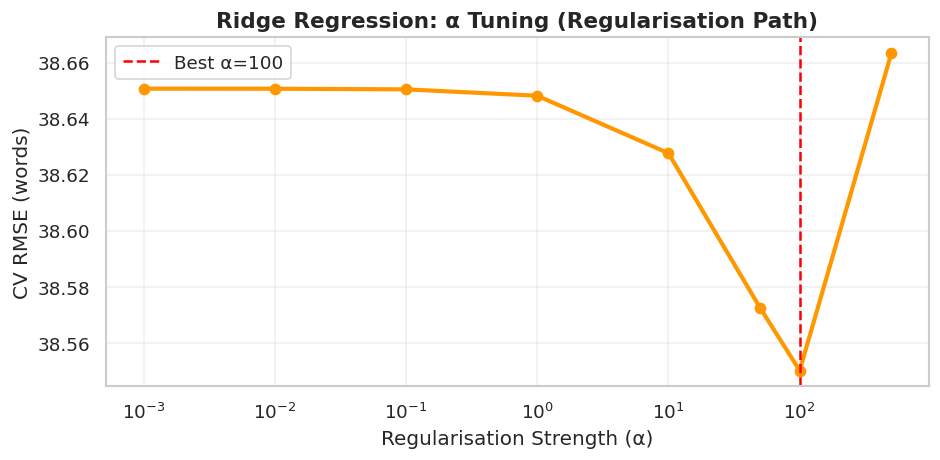

In [15]:
ridge_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('ridge',  Ridge())
])

ridge_grid = {
    'ridge__alpha': [0.001, 0.01, 0.1, 1, 10, 50, 100, 500]
}

kf = KFold(n_splits=5, shuffle=True, random_state=42)

ridge_gs = GridSearchCV(
    ridge_pipe, ridge_grid,
    cv=kf, scoring='neg_root_mean_squared_error',
    n_jobs=-1
)
ridge_gs.fit(X_b_train, y_b_train)

print(f'Best alpha : {ridge_gs.best_params_}')
print(f'Best CV RMSE: {-ridge_gs.best_score_:.4f}')

# plot regularisation path
alphas  = [p['ridge__alpha'] for p in ridge_gs.cv_results_['params']]
cv_rmse = -ridge_gs.cv_results_['mean_test_score']

fig, ax = plt.subplots(figsize=(8, 4))
ax.semilogx(alphas, cv_rmse, marker='o', color='#FF9800', linewidth=2.5)
ax.axvline(ridge_gs.best_params_['ridge__alpha'], color='red', linestyle='--',
           label=f"Best α={ridge_gs.best_params_['ridge__alpha']}")
ax.set_xlabel('Regularisation Strength (α)', fontsize=12)
ax.set_ylabel('CV RMSE (words)', fontsize=12)
ax.set_title('Ridge Regression: α Tuning (Regularisation Path)', fontsize=13, fontweight='bold')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('ridge_alpha_tuning.png', bbox_inches='tight', dpi=150)
plt.show()

### 4.3 Hyperparameter Tuning — Random Forest Regressor

In [16]:
rf_reg_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('rf',     RandomForestRegressor(random_state=42))
])

rf_reg_grid = {
    'rf__n_estimators'     : [50, 100, 200],
    'rf__max_depth'        : [None, 5, 10],
    'rf__min_samples_split': [2, 5, 10],
}

rf_reg_gs = GridSearchCV(
    rf_reg_pipe, rf_reg_grid,
    cv=kf, scoring='neg_root_mean_squared_error',
    n_jobs=-1
)
rf_reg_gs.fit(X_b_train, y_b_train)

print(f'Best params : {rf_reg_gs.best_params_}')
print(f'Best CV RMSE: {-rf_reg_gs.best_score_:.4f}')

Best params : {'rf__max_depth': 5, 'rf__min_samples_split': 10, 'rf__n_estimators': 50}
Best CV RMSE: 37.9276


### 4.4 Cross-Validation — Regressors

In [17]:
regressors = {
    'Ridge (tuned)'     : ridge_gs.best_estimator_,
    'Random Forest Reg.': rf_reg_gs.best_estimator_,
}

print('5-FOLD CROSS-VALIDATION — REGRESSION')
print('=' * 60)
for name, model in regressors.items():
    rmse_cv = cross_val_score(model, X_b_train, y_b_train,
                              cv=kf, scoring='neg_root_mean_squared_error', n_jobs=-1)
    mae_cv  = cross_val_score(model, X_b_train, y_b_train,
                              cv=kf, scoring='neg_mean_absolute_error', n_jobs=-1)
    r2_cv   = cross_val_score(model, X_b_train, y_b_train,
                              cv=kf, scoring='r2', n_jobs=-1)
    print(f'\n{name}')
    print(f'  CV RMSE : {(-rmse_cv).mean():.3f} ± {(-rmse_cv).std():.3f} words')
    print(f'  CV MAE  : {(-mae_cv).mean():.3f} ± {(-mae_cv).std():.3f} words')
    print(f'  CV R²   : {r2_cv.mean():.4f} ± {r2_cv.std():.4f}')

5-FOLD CROSS-VALIDATION — REGRESSION

Ridge (tuned)
  CV RMSE : 38.550 ± 2.908 words
  CV MAE  : 31.261 ± 1.714 words
  CV R²   : 0.0069 ± 0.0455

Random Forest Reg.
  CV RMSE : 37.928 ± 3.071 words
  CV MAE  : 30.481 ± 2.271 words
  CV R²   : 0.0392 ± 0.0508


### 4.5 Comprehensive Regression Metrics + Residual Analysis

In [18]:
# evaluate both regressors on test set
reg_test_results = {}
for name, model in regressors.items():
    yp = model.predict(X_b_test)
    reg_test_results[name] = {
        'y_pred'  : yp,
        'residuals': y_b_test - yp,
        'rmse'    : np.sqrt(mean_squared_error(y_b_test, yp)),
        'mae'     : mean_absolute_error(y_b_test, yp),
        'r2'      : r2_score(y_b_test, yp),
    }

print('REGRESSION TEST SET METRICS')
print('=' * 60)
print(f'{"Model":<22} {"RMSE":>8} {"MAE":>8} {"R²":>8}')
print('-' * 50)
print(f'{"Dummy (mean)":<22} {rmse_dum:>8.2f} {mean_absolute_error(y_b_test, y_dum_b):>8.2f} {r2_score(y_b_test, y_dum_b):>8.4f}')
for name, res in reg_test_results.items():
    print(f'{name:<22} {res["rmse"]:>8.2f} {res["mae"]:>8.2f} {res["r2"]:>8.4f}')

REGRESSION TEST SET METRICS
Model                      RMSE      MAE       R²
--------------------------------------------------
Dummy (mean)              36.43    30.93  -0.0057
Ridge (tuned)             35.71    30.23   0.0337
Random Forest Reg.        35.84    29.84   0.0269


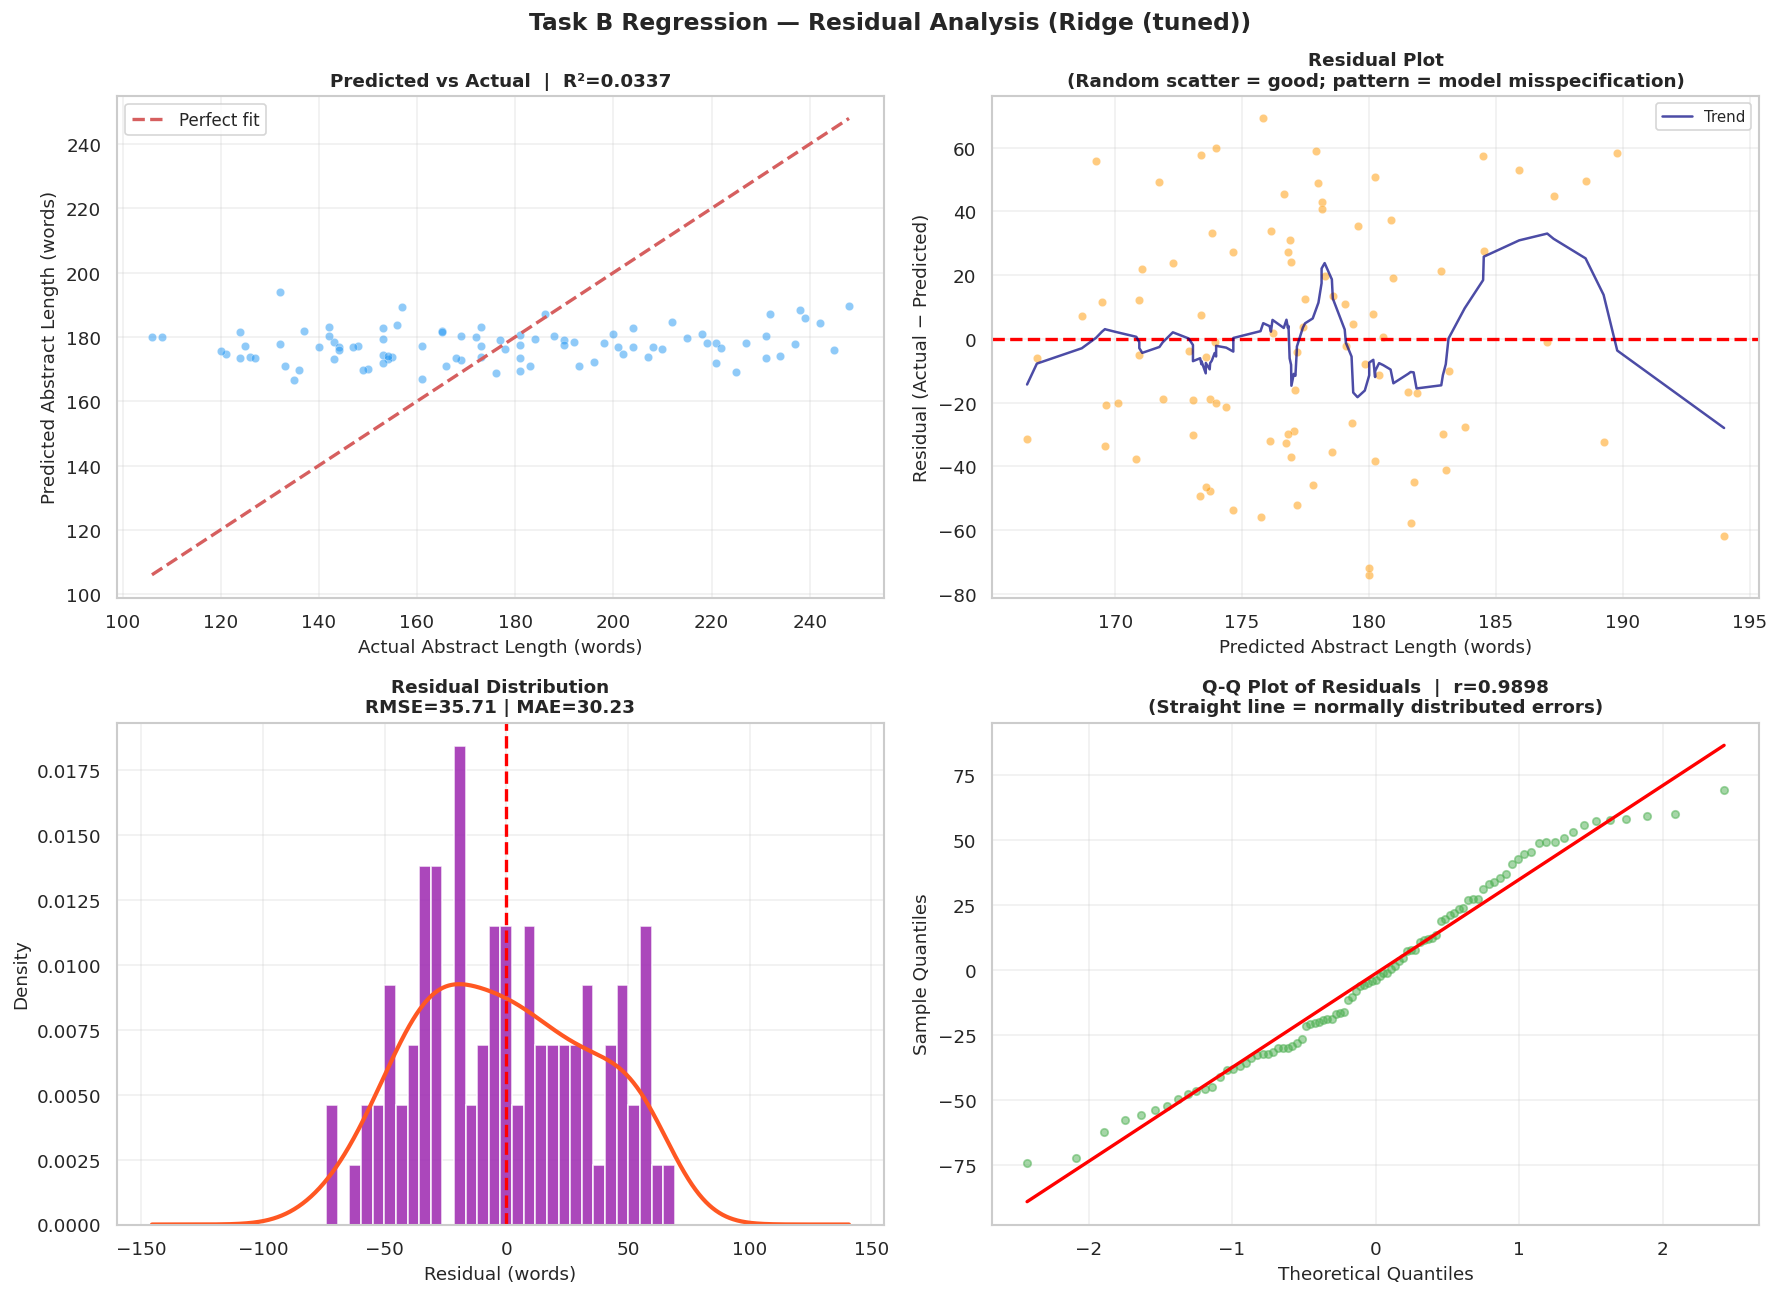


 RMSE = 35.71 words: on average, predictions are off by ~36 words.
 Dummy RMSE = 36.43 → our model improves over mean prediction.
 Residual plot: check for cone shape (heteroscedasticity) or curves (non-linearity).


In [19]:
# residual analysis plots
best_reg_name = min(reg_test_results, key=lambda n: reg_test_results[n]['rmse'])
best_res      = reg_test_results[best_reg_name]

fig, axes = plt.subplots(2, 2, figsize=(15, 11))
fig.suptitle(f'Task B Regression — Residual Analysis ({best_reg_name})',
             fontsize=14, fontweight='bold')

# predicted vs actual
ax = axes[0, 0]
ax.scatter(y_b_test, best_res['y_pred'], alpha=0.5, s=25,
           color='#2196F3', edgecolors='white', linewidths=0.3)
mn, mx = min(y_b_test.min(), best_res['y_pred'].min()), max(y_b_test.max(), best_res['y_pred'].max())
ax.plot([mn, mx], [mn, mx], 'r--', linewidth=2, label='Perfect fit')
ax.set_xlabel('Actual Abstract Length (words)', fontsize=11)
ax.set_ylabel('Predicted Abstract Length (words)', fontsize=11)
ax.set_title(f'Predicted vs Actual  |  R²={best_res["r2"]:.4f}', fontsize=11, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(alpha=0.3)

# residual plot (residuals vs predicted)
ax = axes[0, 1]
ax.scatter(best_res['y_pred'], best_res['residuals'],
           alpha=0.5, s=25, color='#FF9800', edgecolors='white', linewidths=0.3)
ax.axhline(0, color='red', linestyle='--', linewidth=2)

# smoothed trend line
sort_idx = np.argsort(best_res['y_pred'])
from scipy.signal import savgol_filter
try:
    smoothed = savgol_filter(best_res['residuals'][sort_idx], 21, 3)
    ax.plot(best_res['y_pred'][sort_idx], smoothed, color='navy', linewidth=1.5, alpha=0.7, label='Trend')
    ax.legend(fontsize=9)
except Exception:
    pass
ax.set_xlabel('Predicted Abstract Length (words)', fontsize=11)
ax.set_ylabel('Residual (Actual − Predicted)', fontsize=11)
ax.set_title('Residual Plot\n(Random scatter = good; pattern = model misspecification)', fontsize=11, fontweight='bold')
ax.grid(alpha=0.3)

# residual histogram
ax = axes[1, 0]
ax.hist(best_res['residuals'], bins=30, color='#9C27B0', edgecolor='white', alpha=0.85, density=True)
pd.Series(best_res['residuals']).plot.kde(ax=ax, color='#FF5722', linewidth=2.5)
ax.axvline(0, color='red', linestyle='--', linewidth=2)
ax.set_xlabel('Residual (words)', fontsize=11)
ax.set_ylabel('Density', fontsize=11)
ax.set_title(f'Residual Distribution\nRMSE={best_res["rmse"]:.2f} | MAE={best_res["mae"]:.2f}',
             fontsize=11, fontweight='bold')
ax.grid(alpha=0.3)

# Q-Q plot of residuals
ax = axes[1, 1]
(osm, osr), (slope, intercept, r) = stats.probplot(best_res['residuals'])
ax.scatter(osm, osr, alpha=0.5, s=20, color='#4CAF50')
x_qq = np.array([min(osm), max(osm)])
ax.plot(x_qq, slope * x_qq + intercept, color='red', linewidth=2)
ax.set_xlabel('Theoretical Quantiles', fontsize=11)
ax.set_ylabel('Sample Quantiles', fontsize=11)
ax.set_title(f'Q-Q Plot of Residuals  |  r={r:.4f}\n(Straight line = normally distributed errors)',
             fontsize=11, fontweight='bold')
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('regression_residuals.png', bbox_inches='tight', dpi=150)
plt.show()

print(f'\n RMSE = {best_res["rmse"]:.2f} words: on average, predictions are off by ~{best_res["rmse"]:.0f} words.')
print(f' Dummy RMSE = {rmse_dum:.2f} → our model improves over mean prediction.')
print(' Residual plot: check for cone shape (heteroscedasticity) or curves (non-linearity).')

---
## 5. Feature Importance

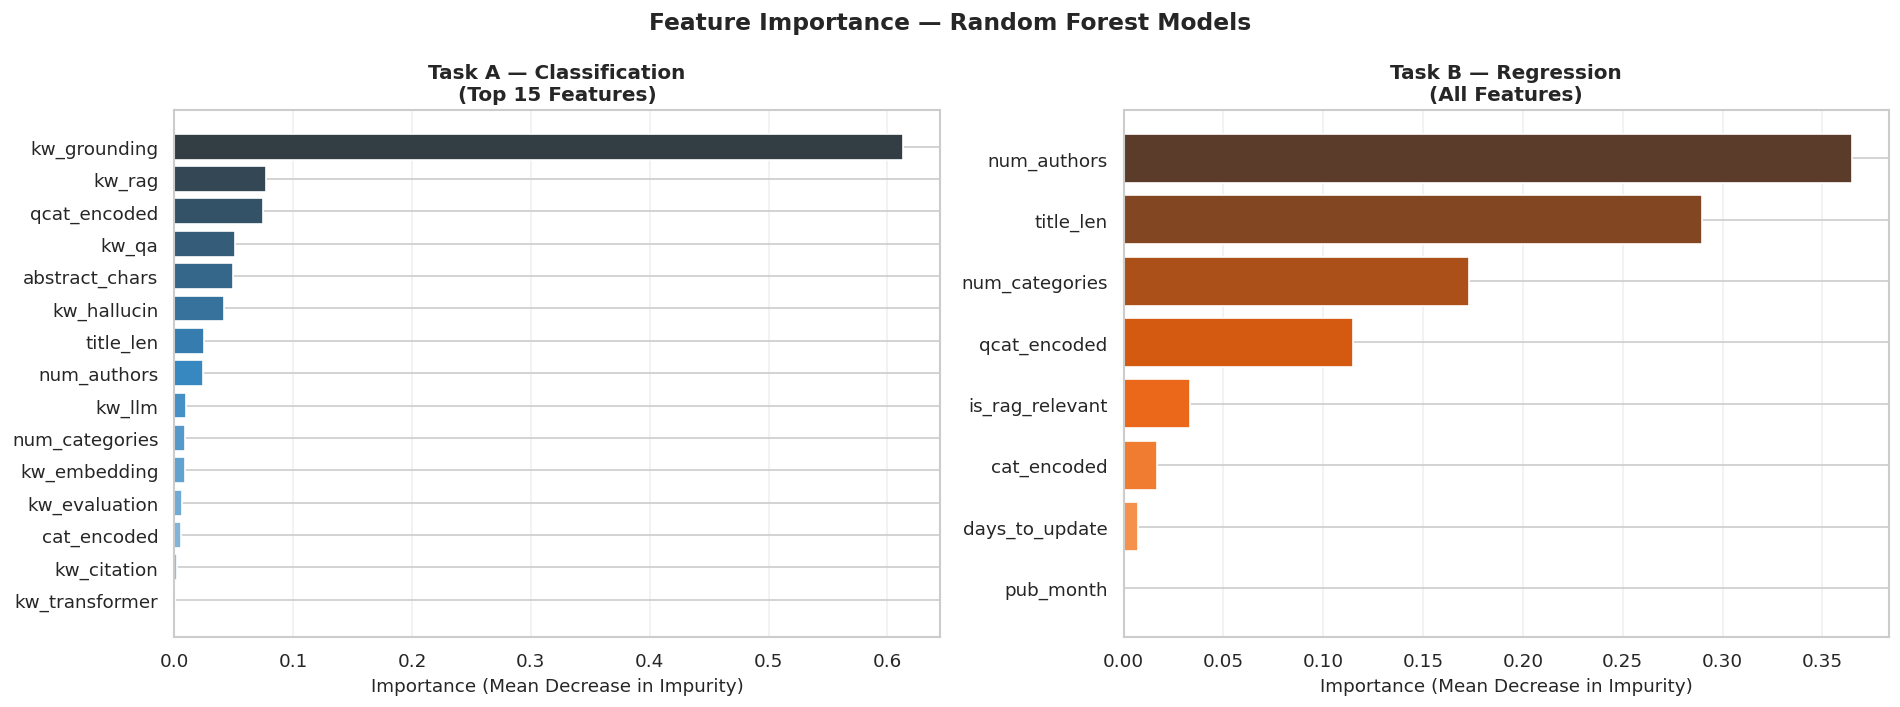

 Task A top features: keyword flags (kw_rag, kw_hallucin) dominate —
   confirms that textual signals are the strongest predictors of relevance.
 Task B: num_authors & num_categories drive abstract length variations.


In [20]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Feature Importance — Random Forest Models', fontsize=14, fontweight='bold')

# classification importance
rf_clf_model = rf_clf_gs.best_estimator_.named_steps['rf']
imp_a   = rf_clf_model.feature_importances_
feat_a  = FEATS_A
idx_a   = np.argsort(imp_a)[::-1][:15]

axes[0].barh([feat_a[i] for i in idx_a[::-1]], imp_a[idx_a[::-1]],
             color=sns.color_palette('Blues_d', 15))
axes[0].set_xlabel('Importance (Mean Decrease in Impurity)', fontsize=11)
axes[0].set_title('Task A — Classification\n(Top 15 Features)', fontsize=12, fontweight='bold')
axes[0].grid(axis='x', alpha=0.3)

# regression importance
rf_reg_model = rf_reg_gs.best_estimator_.named_steps['rf']
imp_b   = rf_reg_model.feature_importances_
feat_b  = FEATS_B
idx_b   = np.argsort(imp_b)[::-1]

axes[1].barh([feat_b[i] for i in idx_b[::-1]], imp_b[idx_b[::-1]],
             color=sns.color_palette('Oranges_d', len(feat_b)))
axes[1].set_xlabel('Importance (Mean Decrease in Impurity)', fontsize=11)
axes[1].set_title('Task B — Regression\n(All Features)', fontsize=12, fontweight='bold')
axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('feature_importance.png', bbox_inches='tight', dpi=150)
plt.show()

print(' Task A top features: keyword flags (kw_rag, kw_hallucin) dominate —')
print('   confirms that textual signals are the strongest predictors of relevance.')
print(' Task B: num_authors & num_categories drive abstract length variations.')

---
## 6. Group Roles & Responsibilities

**Anisha Gehlot**: Feature selection rationale, categorical encoding, train/test split design

**Moulya Reddygari Bhupal**: Data reload pipeline, Task A kNN + Logistic Regression tuning

**Sreyesh Varma Konduru**: Task A Random Forest tuning, cross-validation framework, metrics computation

**Karthikeya Myneedu**: Task B regression models, residual analysis plots, summary visualisations